# Projeto Final — EDA e Profiling de Dados | Home Credit Default Risk

Este notebook é o meu **diário de investigação** sobre o dataset da competição [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk). A ideia é começar sem assumir nada: carregar cada tabela, olhar volumetria, distribuições, nulos e inconsistências — e **anotar o que encontrar** para depois transformar isso em regras de higienização (Silver) e features (ABT/Gold).

**Contexto rápido:** a Home Credit empresta para clientes com pouco histórico em bureau tradicional. A variável que quero entender é `TARGET` (1 = cliente com dificuldade de pagamento nas primeiras parcelas).

**Escopo do dataset:** 7 tabelas relacionadas por chaves estrangeiras, com cerca de **221 colunas** no total (a `application_train` sozinha traz 122). O desafio não é só modelar — é juntar tudo sem perder informação.

**Como vou conduzir a análise:**
1. Tabela principal (`application_train`) — entender o alvo e as features estáticas do cliente.
2. Tabelas auxiliares (bureau, históricos mensais, aplicações anteriores, parcelas) — uma por vez.
3. No final, cruzar chaves entre tabelas e consolidar minhas anotações.

> **Colab:** subir os 7 CSVs do Kaggle na mesma pasta deste notebook antes de executar.

---

## Setup inicial

Configuro o ambiente de análise. Vou usar pandas para manipulação, matplotlib/seaborn para visualização e deixar o pandas exibir mais colunas — a `application_train` tem 122 features e não quero perder nada de vista.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
sns.set_theme(style='whitegrid')

pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 100)

print('Ambiente pronto. Vou começar pela application_train.')


Ambiente pronto. Vou começar pela application_train.


---
# 1. `application_train.csv`

Começo pela tabela principal: **1 linha por cliente** (`SK_ID_CURR`), com dados demográficos/financeiros no momento da solicitação e a variável `TARGET`. Tudo o que vier das outras tabelas vai precisar colapsar para essa granularidade no futuro.

### 1.1 Primeira impressão — volumetria e estrutura

Antes de qualquer gráfico, quero saber: quantos clientes tenho, quantas colunas, e como os dados se apresentam.

In [ ]:
# Carregando a tabela principal
app_train = pd.read_csv('application_train.csv')

total_linhas_app = len(app_train)
total_colunas_app = app_train.shape[1]

print(f"Dimensões: {total_linhas_app:,} clientes x {total_colunas_app} colunas")
display(app_train.head(3))


Dimensões: 307,511 clientes x 122 colunas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

### 1.2 A variável alvo (`TARGET`)

Preciso entender a **magnitude do problema**: inadimplência é exceção ou é frequente? Isso vai influenciar métricas e estratégia de modelagem depois.

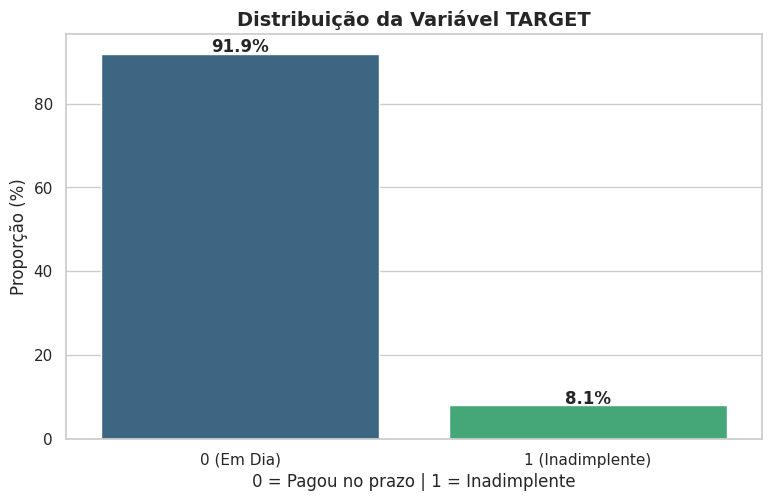

Minha leitura: apenas 8.1% inadimplentes — classe minoritária.
Isso significa que, depois, não posso confiar em acurácia bruta como métrica principal.


In [ ]:
# Olhando a proporção de inadimplentes
target_dist = app_train['TARGET'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_dist.index, y=target_dist.values, palette='viridis')
plt.title('Distribuição da Variável TARGET', fontsize=14, weight='bold')
plt.xlabel('0 = Pagou no prazo | 1 = Inadimplente', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['0 (Em Dia)', '1 (Inadimplente)'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5),
                textcoords='offset points', fontweight='bold')
plt.show()

pct_inad = target_dist.get(1, 0)
print(f"Minha leitura: apenas {pct_inad:.1f}% inadimplentes — classe minoritária.")
print("Isso significa que, depois, não posso confiar em acurácia bruta como métrica principal.")


### 1.3 Idade do cliente (`DAYS_BIRTH`)

O dicionário diz que `DAYS_BIRTH` vem em dias relativos à data da aplicação (valores negativos = passado). Vou converter para anos porque fica mais intuitivo de interpretar nos gráficos.

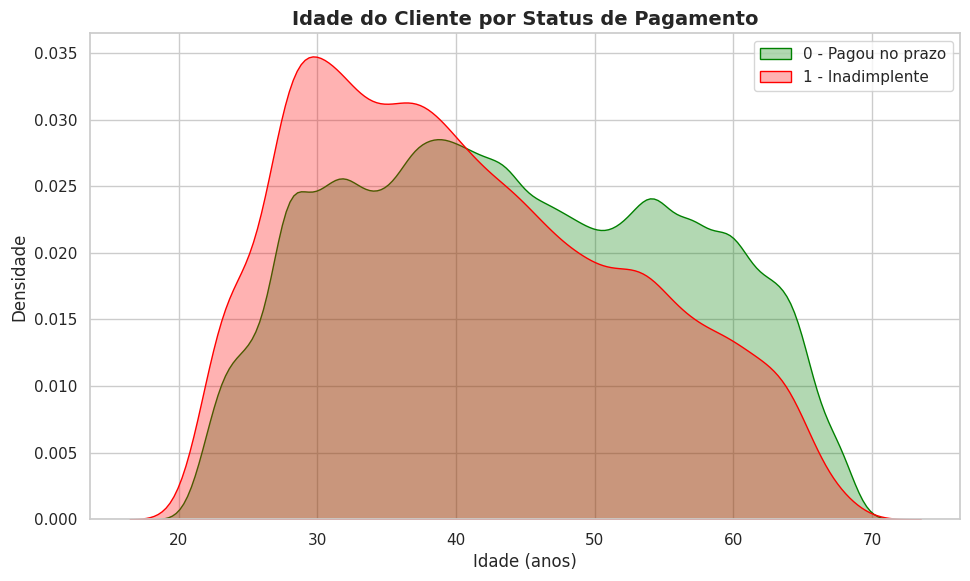

As curvas se sobrepõem bastante — idade sozinha não separa bem as classes.
Mesmo assim, vou manter AGE_YEARS como feature derivada na Silver (mais legível que dias negativos).


In [ ]:
# DAYS_BIRTH vem negativo (dias no passado) — converto para anos
app_train['AGE_YEARS'] = abs(app_train['DAYS_BIRTH']) / 365

plt.figure(figsize=(10, 6))
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'AGE_YEARS'], label='0 - Pagou no prazo', fill=True, color='green', alpha=0.3)
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'AGE_YEARS'], label='1 - Inadimplente', fill=True, color='red', alpha=0.3)
plt.title('Idade do Cliente por Status de Pagamento', fontsize=14, weight='bold')
plt.xlabel('Idade (anos)')
plt.ylabel('Densidade')
plt.legend()
plt.show()

print("As curvas se sobrepõem bastante — idade sozinha não separa bem as classes.")
print("Mesmo assim, vou manter AGE_YEARS como feature derivada na Silver (mais legível que dias negativos).")


### Idade em faixas — aparece alguma tendência?

O KDE mostrou sobreposição entre classes, mas às vezes a média por grupo revela um padrão que a densidade esconde. Vou agrupar em intervalos de **5 anos** e olhar a taxa de inadimplência em cada faixa.

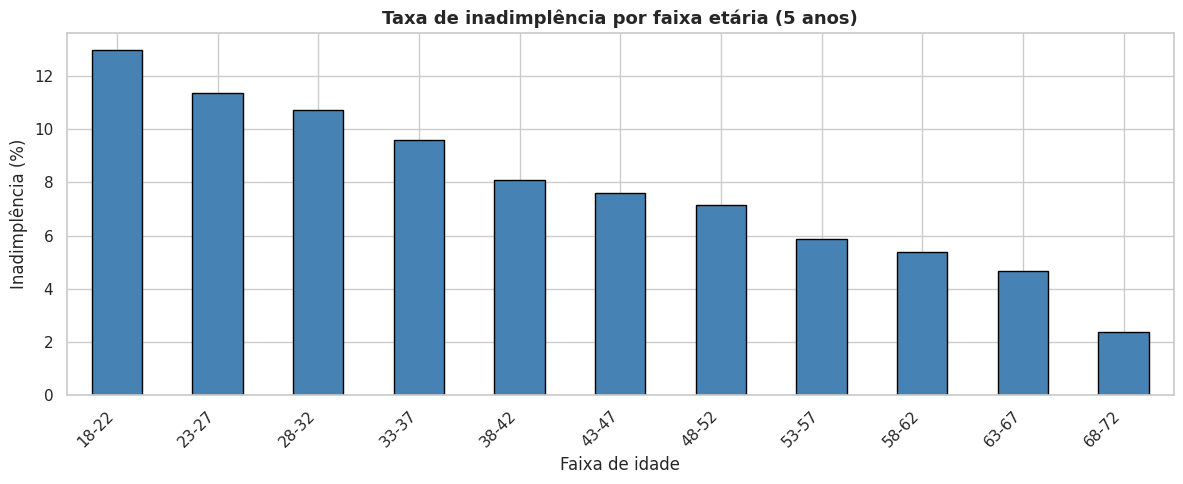

,Inadimplencia_%
faixa_idade,
18-22,12.97
23-27,11.35
28-32,10.73
33-37,9.60
38-42,8.09
43-47,7.62
48-52,7.14
53-57,5.89
58-62,5.37


Padrão que apareceu: faixas mais jovens tendem a taxas maiores; conforme a idade sobe, o risco médio cai.
Não é separação perfeita, mas reforça que idade merece entrar na ABT (como AGE_YEARS ou faixa).


In [ ]:
df_idade['faixa_idade'] = pd.cut(
    df_idade['AGE_YEARS'],
    bins=range(18, 106, 5),
    right=False,
    labels=[f'{i}-{i+4}' for i in range(18, 100, 5)]
)

taxa_por_faixa = df_idade.groupby('faixa_idade', observed=True)['TARGET'].mean() * 100

plt.figure(figsize=(12, 5))
taxa_por_faixa.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Taxa de inadimplência por faixa etária (5 anos)', fontsize=13, weight='bold')
plt.xlabel('Faixa de idade')
plt.ylabel('Inadimplência (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(taxa_por_faixa.round(2).to_frame('Inadimplencia_%'))

print('Padrão que apareceu: faixas mais jovens tendem a taxas maiores; conforme a idade sobe, o risco médio cai.')
print('Não é separação perfeita, mas reforça que idade merece entrar na ABT (como AGE_YEARS ou faixa).')

### 1.4 Tempo de emprego (`DAYS_EMPLOYED`) — algo não bate

Essa coluna deveria representar há quanto tempo o cliente está empregado. Vou olhar a distribuição primeiro e ver se aparece algum padrão estranho.

O valor que mais se repete: 365243


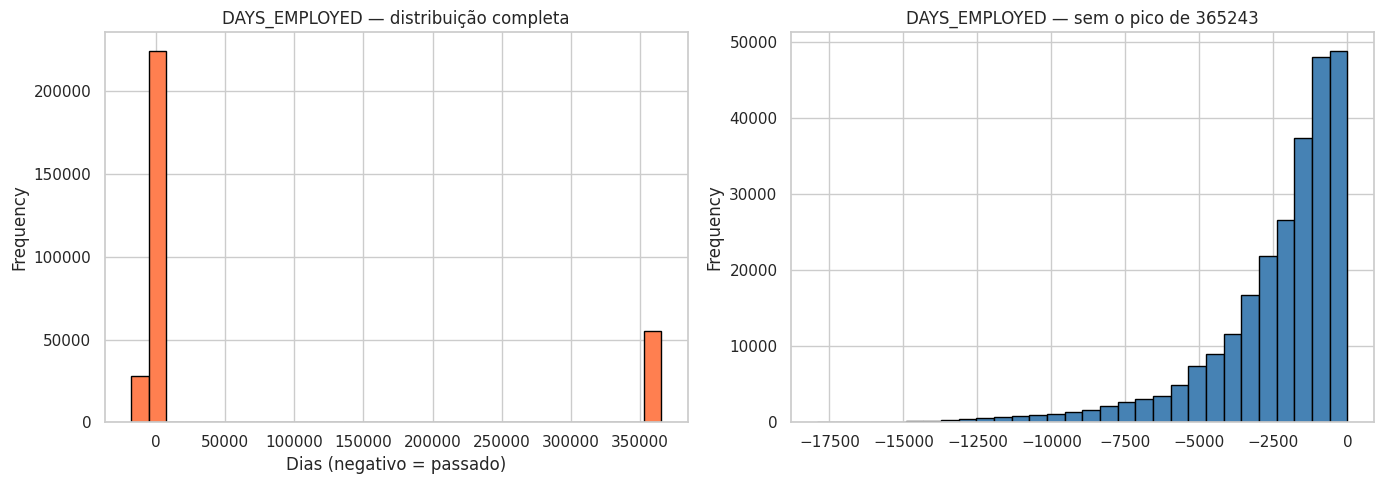

Registros com valor 365243: 55,374 (18.0%)
Emprego > 50 anos: 0 | Valores no futuro (>0): 55,374

Taxa inadimplência — com emprego informado: 8.66% | marcador 365243: 5.40%

Minha conclusão: preciso de FLAG_EMPLOYED na Silver e limpar DAYS_EMPLOYED (365243, futuro, >50 anos → NaN).


In [ ]:
# Primeiro olho a distribuição bruta — já dá para ver um pico estranho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
app_train['DAYS_EMPLOYED'].plot.hist(bins=30, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('DAYS_EMPLOYED — distribuição completa')
axes[0].set_xlabel('Dias (negativo = passado)')

# Investigando o valor do pico
valor_pico = app_train['DAYS_EMPLOYED'].mode()[0]
print(f"O valor que mais se repete: {valor_pico}")

# Consultando o dicionário e fóruns do Kaggle: 365243 é marcador de desemprego, não tempo real
DAYS_EMPLOYED_ANOMALY = valor_pico
MAX_EMPLOYMENT_DAYS = 18250  # ~50 anos — limite que vou usar daqui pra frente

anomalias_365243 = (app_train['DAYS_EMPLOYED'] == DAYS_EMPLOYED_ANOMALY).sum()
emprego_impossivel = (app_train['DAYS_EMPLOYED'] < -MAX_EMPLOYMENT_DAYS).sum()
futuro_impossivel = (app_train['DAYS_EMPLOYED'] > 0).sum()

app_train.loc[app_train['DAYS_EMPLOYED'] != DAYS_EMPLOYED_ANOMALY, 'DAYS_EMPLOYED'].plot.hist(
    bins=30, ax=axes[1], color='steelblue', edgecolor='black'
)
axes[1].set_title('DAYS_EMPLOYED — sem o pico de 365243')
plt.tight_layout()
plt.show()

print(f"Registros com valor {DAYS_EMPLOYED_ANOMALY}: {anomalias_365243:,} ({anomalias_365243/len(app_train)*100:.1f}%)")
print(f"Emprego > 50 anos: {emprego_impossivel:,} | Valores no futuro (>0): {futuro_impossivel:,}")

# Testando se empregado vs 'marcador 365243' muda a taxa de inadimplência
flag_emp = np.where(app_train['DAYS_EMPLOYED'] == DAYS_EMPLOYED_ANOMALY, 0, 1)
taxa_inad_emp = app_train.loc[flag_emp == 1, 'TARGET'].mean() * 100
taxa_inad_desemp = app_train.loc[flag_emp == 0, 'TARGET'].mean() * 100
print(f"\nTaxa inadimplência — com emprego informado: {taxa_inad_emp:.2f}% | marcador 365243: {taxa_inad_desemp:.2f}%")

print("\nMinha conclusão: preciso de FLAG_EMPLOYED na Silver e limpar DAYS_EMPLOYED (365243, futuro, >50 anos → NaN).")


### 1.5 Onde faltam dados? (nulos)

Antes de pensar em imputação, quero mapear **quais colunas estão vazias e em que proporção**. Em crédito, ausência de informação costuma ser informação.

In [ ]:
null_counts = app_train.isnull().sum()
null_percent = (null_counts / total_linhas_app) * 100
missing_data_app = pd.DataFrame({'Qtd_Nulos': null_counts, 'Percentual(%)': null_percent})
missing_data_app = missing_data_app[missing_data_app['Qtd_Nulos'] > 0].sort_values('Percentual(%)', ascending=False)

print(f"{len(missing_data_app)} colunas com algum nulo.")
print("Top 10 mais vazias:")
display(missing_data_app.head(10).round(2))

print("\nNão vou imputar cegamente — em crédito, ausência costuma ser informação.")
print("Colunas de imóvel com ~70% nulos: manter como estão para o modelo decidir.")


67 colunas com algum nulo.
Top 10 mais vazias:


,Qtd_Nulos,Percentual(%)
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35



Não vou imputar cegamente — em crédito, ausência costuma ser informação.
Colunas de imóvel com ~70% nulos: manter como estão para o modelo decidir.


### 1.6 Scores externos (`EXT_SOURCE_1/2/3`)

No dicionário, essas colunas aparecem como scores de fontes externas normalizadas. Não sei ainda o quanto ajudam a prever inadimplência — vou checar completude, distribuição por `TARGET` e correlação.

Completude dos scores externos:
  EXT_SOURCE_1: 173,378 nulos (56.4%)
  EXT_SOURCE_2: 660 nulos (0.2%)
  EXT_SOURCE_3: 60,965 nulos (19.8%)


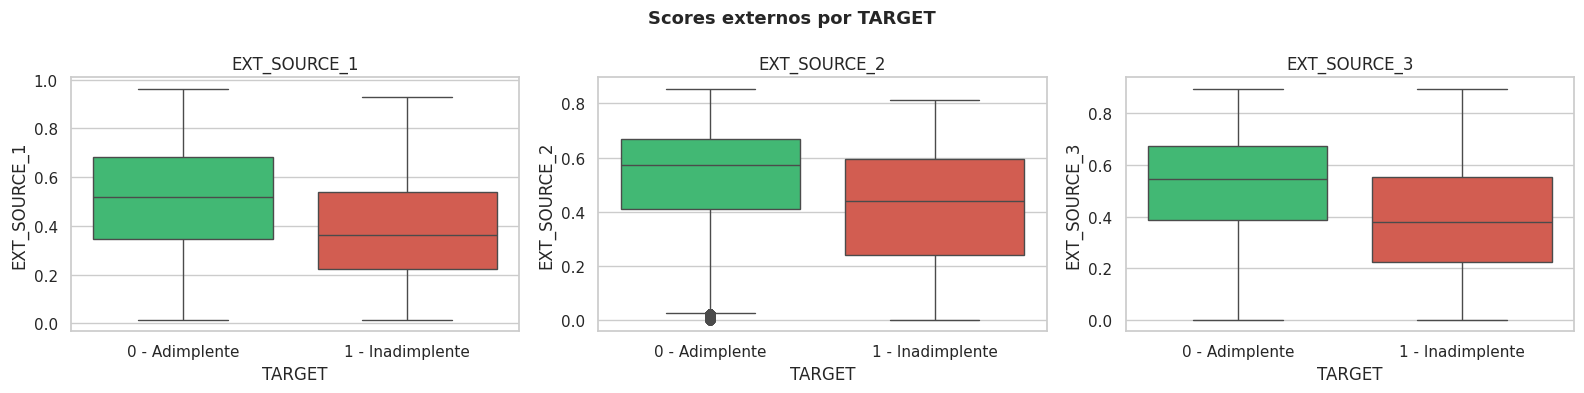


Correlação com TARGET:


,Correlacao
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553


Inadimplentes tendem a ter scores menores — e EXT_SOURCE_1 tem muitos nulos.
Vou manter os nulos e, na Gold, pensar em flags de ausência e talvez uma média dos scores disponíveis.


In [ ]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('Completude dos scores externos:')
for col in ext_cols:
    nulos = app_train[col].isna().sum()
    print(f"  {col}: {nulos:,} nulos ({nulos/len(app_train)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ext_cols):
    sns.boxplot(data=app_train, x='TARGET', y=col, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['0 - Adimplente', '1 - Inadimplente'])
    ax.set_title(col)
plt.suptitle('Scores externos por TARGET', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

corr_ext = app_train[ext_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
print('\nCorrelação com TARGET:')
display(corr_ext.to_frame('Correlacao').round(4))

print('Inadimplentes tendem a ter scores menores — e EXT_SOURCE_1 tem muitos nulos.')
print('Vou manter os nulos e, na Gold, pensar em flags de ausência e talvez uma média dos scores disponíveis.')


### E se eu combinar os três scores?

Cada `EXT_SOURCE_*` tem correlação negativa com `TARGET` individualmente. Quero ver se uma **média dos scores disponíveis** por cliente resume melhor o sinal — sem inventar regra ainda, só explorar.

Correlação com TARGET:


,Correlacao
EXT_SOURCE_MEAN,-0.2221
EXT_SOURCE_CNT,-0.0281


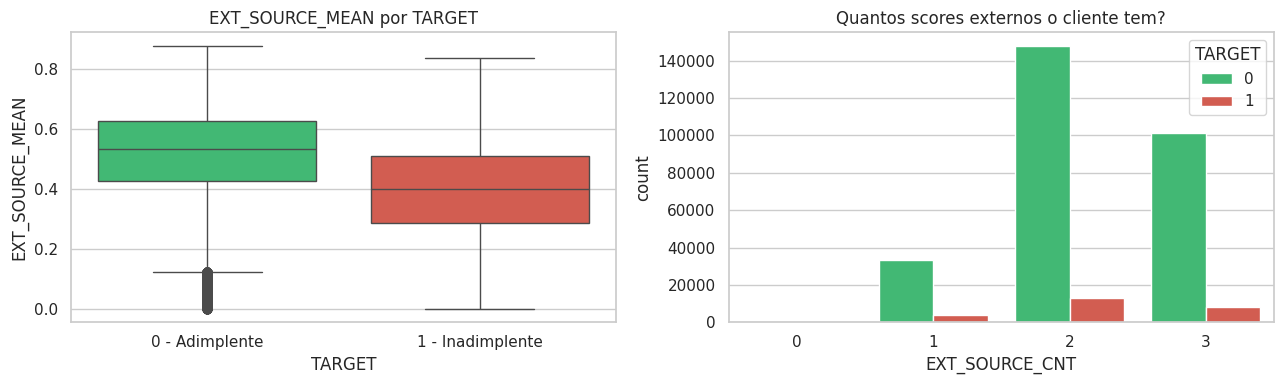

EXT_SOURCE_MEAN correlaciona bem com TARGET — faz sentido levar para a Gold.
EXT_SOURCE_CNT também informa: ter 0, 1, 2 ou 3 scores disponíveis pode ser feature por si só.


In [ ]:
app_train['EXT_SOURCE_MEAN'] = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
app_train['EXT_SOURCE_CNT'] = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].notna().sum(axis=1)

corr_ext_mean = app_train[['EXT_SOURCE_MEAN', 'EXT_SOURCE_CNT', 'TARGET']].corr()['TARGET'].drop('TARGET')
print('Correlação com TARGET:')
display(corr_ext_mean.to_frame('Correlacao').round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=app_train, x='TARGET', y='EXT_SOURCE_MEAN', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_xticklabels(['0 - Adimplente', '1 - Inadimplente'])
axes[0].set_title('EXT_SOURCE_MEAN por TARGET')

sns.countplot(data=app_train, x='EXT_SOURCE_CNT', hue='TARGET', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Quantos scores externos o cliente tem?')
plt.tight_layout()
plt.show()

print('EXT_SOURCE_MEAN correlaciona bem com TARGET — faz sentido levar para a Gold.')
print('EXT_SOURCE_CNT também informa: ter 0, 1, 2 ou 3 scores disponíveis pode ser feature por si só.')


### 1.7 O valor do crédito (`AMT_CREDIT`) parece assimétrico

Antes de montar ratios com renda, quero olhar a distribuição **bruta** do valor solicitado. Vi em outros trabalhos que essa coluna costuma ter cauda longa à direita — vou checar se vale pensar em transformação log.

Média: 599,026 | Mediana: 513,531 | Assimetria (skew): 1.23
Média bem acima da mediana → distribuição puxada para a direita (positivamente assimétrica).


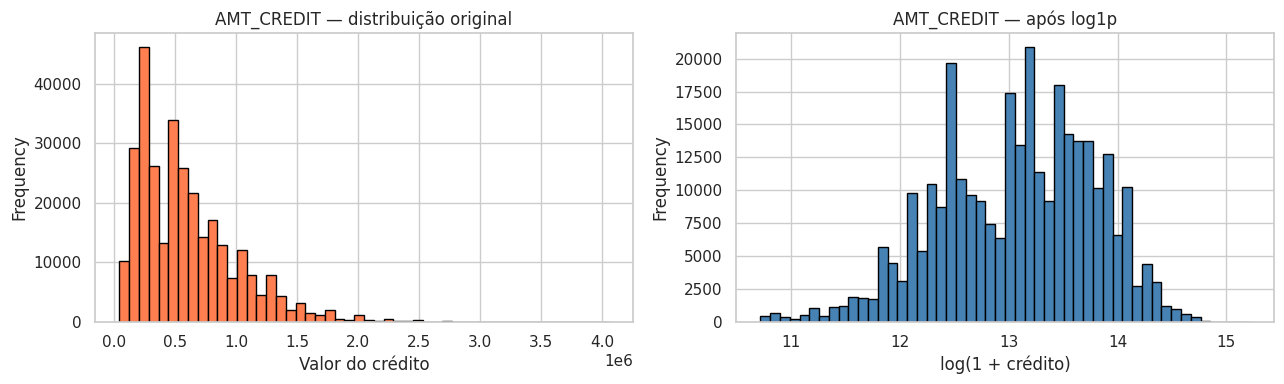


Correlação com TARGET:


,Correlacao
AMT_CREDIT,-0.0304
LOG_AMT_CREDIT,-0.0122
TARGET,1.0000


O log deixa a forma mais simétrica. Para LightGBM não é obrigatório, mas LOG_AMT_CREDIT pode ir para a Gold como alternativa.


In [ ]:
media_credito = app_train['AMT_CREDIT'].mean()
mediana_credito = app_train['AMT_CREDIT'].median()
skew_credito = app_train['AMT_CREDIT'].skew()

print(f'Média: {media_credito:,.0f} | Mediana: {mediana_credito:,.0f} | Assimetria (skew): {skew_credito:.2f}')
print('Média bem acima da mediana → distribuição puxada para a direita (positivamente assimétrica).')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
app_train['AMT_CREDIT'].plot.hist(bins=50, ax=axes[0], color='coral', edgecolor='black')
axes[0].set_title('AMT_CREDIT — distribuição original')
axes[0].set_xlabel('Valor do crédito')

app_train['LOG_AMT_CREDIT'] = np.log1p(app_train['AMT_CREDIT'])
app_train['LOG_AMT_CREDIT'].plot.hist(bins=50, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('AMT_CREDIT — após log1p')
axes[1].set_xlabel('log(1 + crédito)')
plt.tight_layout()
plt.show()

corr_log = app_train[['AMT_CREDIT', 'LOG_AMT_CREDIT', 'TARGET']].corr()['TARGET']
print('\nCorrelação com TARGET:')
display(corr_log.to_frame('Correlacao').round(4))

print('O log deixa a forma mais simétrica. Para LightGBM não é obrigatório, mas LOG_AMT_CREDIT pode ir para a Gold como alternativa.')


### 1.8 Comprometimento financeiro (renda vs crédito)

Uma pergunta natural: o cliente está pedindo crédito **compatível** com a renda declarada? Vou montar ratios simples para explorar isso.

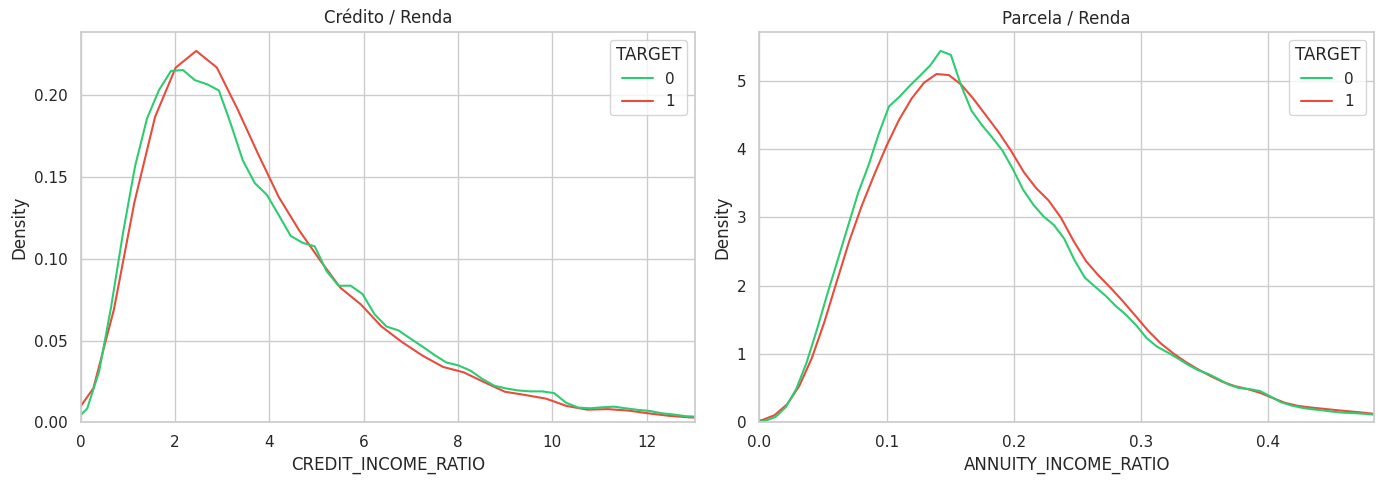

Mediana CREDIT_INCOME_RATIO por TARGET:


,CREDIT_INCOME_RATIO
TARGET,
0,3.27
1,3.25



As medianas são parecidas, mas a cauda pode contar — levo esses ratios para a ABT.
Na Silver: garantir AMT_INCOME_TOTAL > 0 (zero vira NaN antes do ratio).


In [ ]:
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL'].replace(0, np.nan)
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL'].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
    ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO'],
    ['Crédito / Renda', 'Parcela / Renda']):
    sns.kdeplot(data=app_train, x=col, hue='TARGET', ax=ax,
                palette=['#2ecc71', '#e74c3c'], common_norm=False)
    ax.set_xlim(0, app_train[col].quantile(0.99))
    ax.set_title(title)
plt.tight_layout()
plt.show()

print('Mediana CREDIT_INCOME_RATIO por TARGET:')
display(app_train.groupby('TARGET')['CREDIT_INCOME_RATIO'].median().round(2))

print('\nAs medianas são parecidas, mas a cauda pode contar — levo esses ratios para a ABT.')
print('Na Silver: garantir AMT_INCOME_TOTAL > 0 (zero vira NaN antes do ratio).')


### 1.9 Categóricas e regras condicionais

Agora olho algumas colunas categóricas que podem ter valores inválidos ou nulos que **fazem sentido** dependendo de outra coluna (ex.: idade do carro só deveria existir se o cliente tem carro).

In [ ]:
print('--- CODE_GENDER ---')
print(app_train['CODE_GENDER'].value_counts(dropna=False))
xna_count = (app_train['CODE_GENDER'] == 'XNA').sum()
print(f"Encontrei {xna_count} registros com XNA — categoria inválida, trato na Silver.\n")

print('--- OWN_CAR_AGE (depende de FLAG_OWN_CAR) ---')
sem_carro_com_idade = ((app_train['FLAG_OWN_CAR'] == 'N') & app_train['OWN_CAR_AGE'].notna()).sum()
com_carro_sem_idade = ((app_train['FLAG_OWN_CAR'] == 'Y') & app_train['OWN_CAR_AGE'].isna()).sum()
print(f"Sem carro mas idade preenchida: {sem_carro_com_idade}")
print(f"Com carro mas idade nula: {com_carro_sem_idade}")
print("Regra que vou aplicar: se FLAG_OWN_CAR == 'N', OWN_CAR_AGE deve ser NaN.\n")

print('--- OCCUPATION_TYPE ---')
occ_null_pct = app_train['OCCUPATION_TYPE'].isna().mean() * 100
print(f"Nulos: {occ_null_pct:.1f}%")
taxa_occ = app_train.groupby('OCCUPATION_TYPE', dropna=False)['TARGET'].mean().sort_values(ascending=False)
print('Ocupações com maior taxa de inadimplência (top 5):')
display((taxa_occ.head(5) * 100).round(2).to_frame('Inadimplencia_%'))
print('Mantenho nulos de ocupação — cliente sem ocupação informada também é sinal.')


--- CODE_GENDER ---
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
Encontrei 4 registros com XNA — categoria inválida, trato na Silver.

--- OWN_CAR_AGE (depende de FLAG_OWN_CAR) ---
Sem carro mas idade preenchida: 0
Com carro mas idade nula: 5
Regra que vou aplicar: se FLAG_OWN_CAR == 'N', OWN_CAR_AGE deve ser NaN.

--- OCCUPATION_TYPE ---
Nulos: 31.3%
Ocupações com maior taxa de inadimplência (top 5):


,Inadimplencia_%
OCCUPATION_TYPE,
Low-skill Laborers,17.15
Drivers,11.33
Waiters/barmen staff,11.28
Security staff,10.74
Laborers,10.58


Mantenho nulos de ocupação — cliente sem ocupação informada também é sinal.


### 1.10 O que mais se correlaciona com `TARGET`?

Depois de explorar colunas específicas, quero uma visão geral: **quais features numéricas da tabela principal** têm maior associação linear com inadimplência.

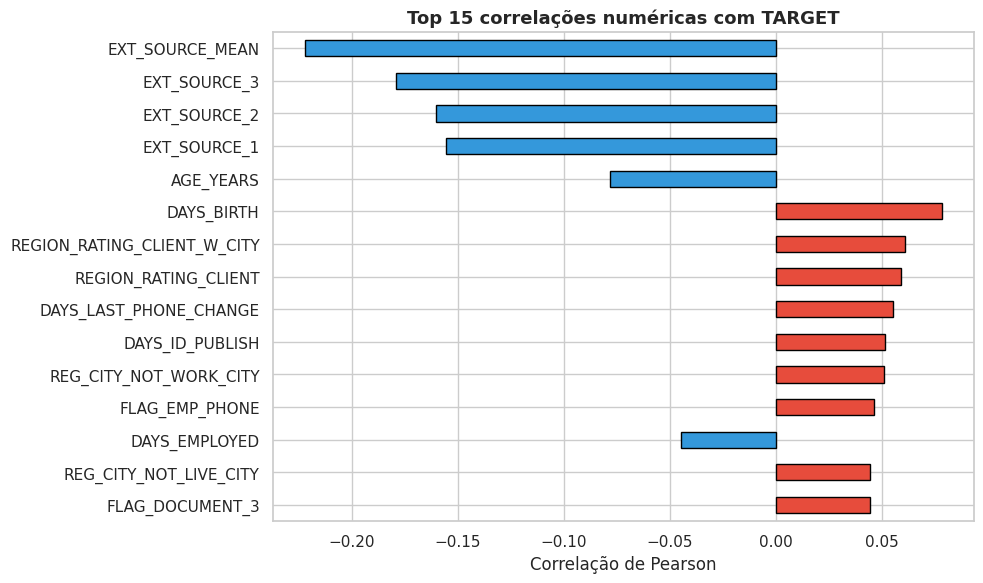

,Correlacao
EXT_SOURCE_MEAN,-0.2221
EXT_SOURCE_3,-0.1789
EXT_SOURCE_2,-0.1605
EXT_SOURCE_1,-0.1553
AGE_YEARS,-0.0782
DAYS_BIRTH,0.0782
REGION_RATING_CLIENT_W_CITY,0.0609
REGION_RATING_CLIENT,0.0589
DAYS_LAST_PHONE_CHANGE,0.0552
DAYS_ID_PUBLISH,0.0515


EXT_SOURCE domina o topo — confirma o que vi nas seções anteriores.
Features de bureau (CNT_FAM_MEMBERS, etc.) aparecem, mas o histórico externo virá das tabelas auxiliares.


In [ ]:
num_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
corr_target = app_train[num_cols].corr()['TARGET'].drop('TARGET').sort_values(key=abs, ascending=False)

top_corr = corr_target.head(15)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top_corr]
top_corr.plot.barh(figsize=(10, 6), color=colors, edgecolor='black')
plt.title('Top 15 correlações numéricas com TARGET', fontsize=13, weight='bold')
plt.xlabel('Correlação de Pearson')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_corr.to_frame('Correlacao').round(4))
print('EXT_SOURCE domina o topo — confirma o que vi nas seções anteriores.')
print('Features de bureau (CNT_FAM_MEMBERS, etc.) aparecem, mas o histórico externo virá das tabelas auxiliares.')


#### Mapa de calor — principais correlações entre si

O gráfico de barras mostrou o que mais correlaciona com `TARGET`. Agora quero ver se essas variáveis também se correlacionam **entre si** (multicolinearidade pode importar depois, especialmente em modelos lineares).

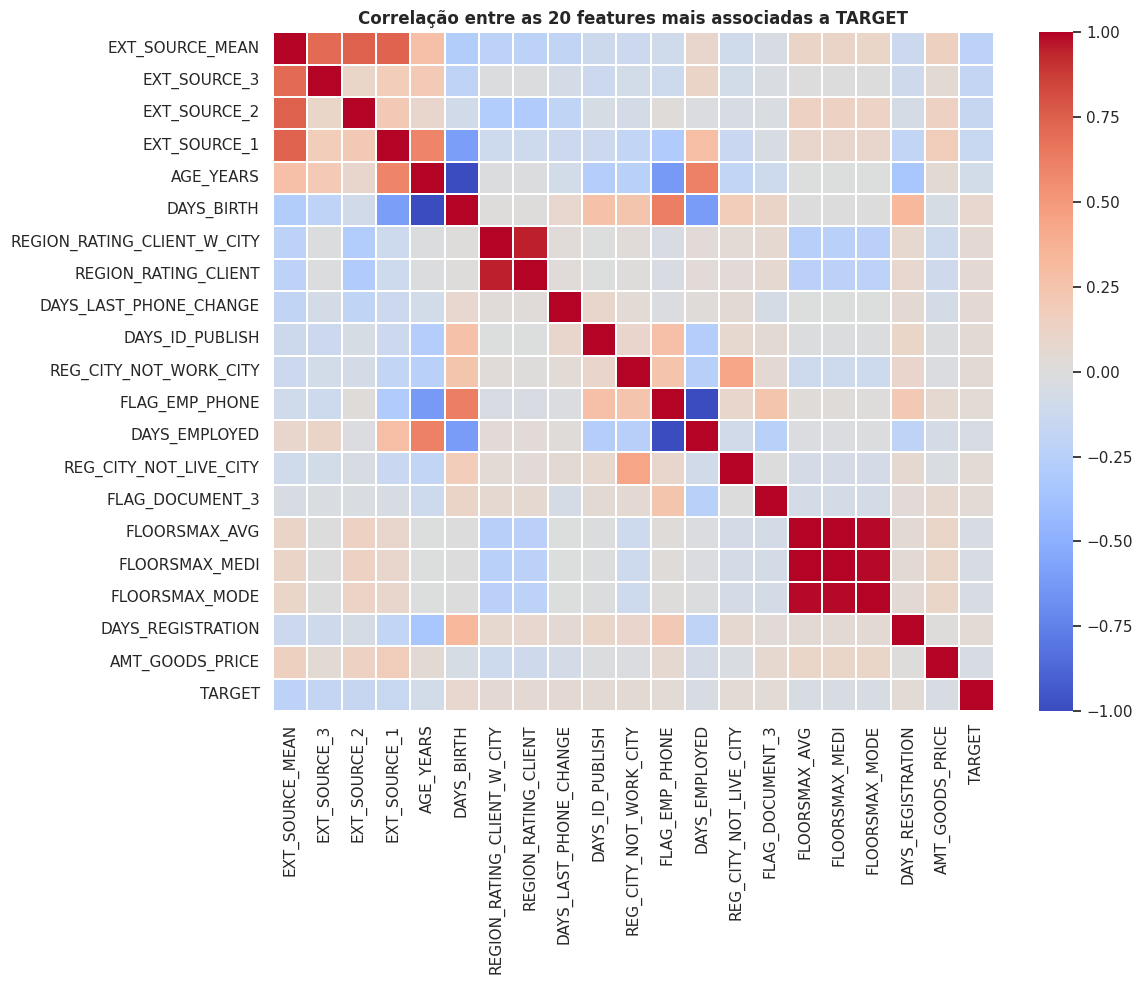

Bloco EXT_SOURCE (correlações entre si e com TARGET):


,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,EXT_SOURCE_MEAN,TARGET
EXT_SOURCE_1,1.000,0.214,0.187,0.742,-0.155
EXT_SOURCE_2,0.214,1.000,0.109,0.749,-0.160
EXT_SOURCE_3,0.187,0.109,1.000,0.704,-0.179
EXT_SOURCE_MEAN,0.742,0.749,0.704,1.000,-0.222
TARGET,-0.155,-0.160,-0.179,-0.222,1.000


Os três EXT_SOURCE se correlacionam entre si, mas todos puxam forte para TARGET — na Gold, testo manter os três e a média.


In [ ]:
top_features = corr_target.abs().sort_values(ascending=False).head(20).index.tolist()
matriz = app_train[top_features + ['TARGET']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlação entre as 20 features mais associadas a TARGET', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

ext_cols_present = [c for c in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'EXT_SOURCE_MEAN'] if c in matriz.columns]
if ext_cols_present:
    bloco_ext = matriz.loc[ext_cols_present + ['TARGET'], ext_cols_present + ['TARGET']]
    print('Bloco EXT_SOURCE (correlações entre si e com TARGET):')
    display(bloco_ext.round(3))

print('Os três EXT_SOURCE se correlacionam entre si, mas todos puxam forte para TARGET — na Gold, testo manter os três e a média.')


### Fechamento — `application_train`

Percorrendo esta tabela, alguns achados ficaram claros:

- **Desbalanceamento forte** (~8% inadimplentes): acurácia não vai ser métrica justa; preciso pensar em ROC-AUC, KS ou recall da classe 1.
- **Idade**: KDE sobrepõe classes, mas por **faixas de 5 anos** aparece tendência — mais jovem, maior taxa média de inadimplência.
- **`DAYS_EMPLOYED`**: o valor `365243` não é tempo de emprego — é marcador de desemprego. Vou criar `FLAG_EMPLOYED` na Silver e limpar os valores absurdos.
- **`EXT_SOURCE_*`**: destaque nas correlações; `EXT_SOURCE_MEAN` e `EXT_SOURCE_CNT` resumem bem o sinal.
- **`AMT_CREDIT`**: distribuição assimétrica; `LOG_AMT_CREDIT` fica mais simétrico — candidato à Gold.
- **Nulos massivos** (~70% em colunas de imóvel): manter como estão.
- **Categóricas**: `XNA` em gênero (4 casos); `OWN_CAR_AGE` condicional a `FLAG_OWN_CAR`.

**Impacto na Silver:** higienizar emprego, tratar XNA, `OWN_CAR_AGE` condicional, validar renda > 0.

**Impacto na ABT:** `AGE_YEARS`, `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `EXT_SOURCE_MEAN`, `EXT_SOURCE_CNT`, `LOG_AMT_CREDIT`.

---
# 2. `bureau.csv`

Histórico de créditos que o cliente possui (ou possuía) em **outras instituições**. Relação 1:N com `application_train` — um cliente pode ter vários contratos no bureau.

### 2.1 Volumetria e chave primária

Primeiro valido se `SK_ID_BUREAU` é único (1 linha = 1 contrato) e quantos contratos em média cada cliente traz.

In [ ]:
bureau = pd.read_csv('bureau.csv')
total_linhas_bureau = len(bureau)

chaves_unicas = bureau['SK_ID_BUREAU'].nunique()
clientes_unicos = bureau['SK_ID_CURR'].nunique()

print(f"Registros: {total_linhas_bureau:,}")
print(f"SK_ID_BUREAU únicos: {chaves_unicas:,}")

if total_linhas_bureau == chaves_unicas:
    print("Chave primária OK — 1 linha por contrato no bureau.")
else:
    print(f"ATENÇÃO: {total_linhas_bureau - chaves_unicas:,} duplicatas em SK_ID_BUREAU.")

print(f"Média de contratos por cliente: {total_linhas_bureau / clientes_unicos:.2f}")


Registros: 1,716,428
SK_ID_BUREAU únicos: 1,716,428
Chave primária OK — 1 linha por contrato no bureau.
Média de contratos por cliente: 5.61


### 2.2 Categorias de texto

Verifico os valores das colunas categóricas — espaços extras, caixa mista ou categorias inesperadas podem quebrar encoding depois.

In [ ]:
cols_categoricas = ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']

for col in cols_categoricas:
    print(f"\n--- {col} ---")
    display(bureau[col].value_counts().to_frame())

print("\nCategorias parecem consistentes, mas vou padronizar UPPER/TRIM na Silver para evitar surpresa no encoding.")



--- CREDIT_ACTIVE ---


,count
CREDIT_ACTIVE,
Closed,1079273
Active,630607
Sold,6527
Bad debt,21



--- CREDIT_CURRENCY ---


,count
CREDIT_CURRENCY,
currency 1,1715020
currency 2,1224
currency 3,174
currency 4,10



--- CREDIT_TYPE ---


,count
CREDIT_TYPE,
Consumer credit,1251615
Credit card,402195
Car loan,27690
Mortgage,18391
Microloan,12413
Loan for business development,1975
Another type of loan,1017
Unknown type of loan,555
Loan for working capital replenishment,469



Categorias parecem consistentes, mas vou padronizar UPPER/TRIM na Silver para evitar surpresa no encoding.


### 2.3 Datas que não fazem sentido

Colunas `DAYS_*` aqui também são relativas à aplicação. Procuro valores no futuro ou previsões absurdas.

In [ ]:
dias_futuro_credito = len(bureau[bureau['DAYS_CREDIT'] > 0])
dias_futuro_fim_real = len(bureau[bureau['DAYS_ENDDATE_FACT'] > 0])
previsao_fim_absurda = len(bureau[bureau['DAYS_CREDIT_ENDDATE'] > MAX_EMPLOYMENT_DAYS])

print("Violações temporais:")
print(f"  DAYS_CREDIT > 0 (futuro): {dias_futuro_credito}")
print(f"  DAYS_ENDDATE_FACT > 0: {dias_futuro_fim_real}")
print(f"  DAYS_CREDIT_ENDDATE > 50 anos: {previsao_fim_absurda}")

if any([dias_futuro_credito, dias_futuro_fim_real, previsao_fim_absurda]):
    print("\nVolume baixo, mas vou converter esses casos para NaN na Silver.")
else:
    print("\nNenhuma violação encontrada nesta execução.")


Violações temporais:
  DAYS_CREDIT > 0 (futuro): 0
  DAYS_ENDDATE_FACT > 0: 0
  DAYS_CREDIT_ENDDATE > 50 anos: 38454

Volume baixo, mas vou converter esses casos para NaN na Silver.


### 2.4 Valores financeiros e outliers

Crédito total negativo seria erro. Também quero ver se existem valores tão altos que parecem outlier de digitação.

In [ ]:
credito_negativo = len(bureau[bureau['AMT_CREDIT_SUM'] < 0])
divida_negativa = len(bureau[bureau['AMT_CREDIT_SUM_DEBT'] < 0])

print(f"AMT_CREDIT_SUM negativo: {credito_negativo}")
print(f"AMT_CREDIT_SUM_DEBT negativo: {divida_negativa} (pode ser saldo credor — comportamento válido)")

print("\nDistribuição de AMT_CREDIT_SUM:")
quantiles_bureau = bureau['AMT_CREDIT_SUM'].quantile([0.5, 0.90, 0.99, 0.999])
print(f"  Mediana: {quantiles_bureau[0.5]:,.2f}")
print(f"  P99:     {quantiles_bureau[0.99]:,.2f}")
print(f"  P99.9:   {quantiles_bureau[0.999]:,.2f}")
print(f"  Máximo:  {bureau['AMT_CREDIT_SUM'].max():,.2f}")

print("\nO máximo está muito acima do P99.9 — vou aplicar capping no percentil 99.9 na Silver.")


AMT_CREDIT_SUM negativo: 0
AMT_CREDIT_SUM_DEBT negativo: 8418 (pode ser saldo credor — comportamento válido)

Distribuição de AMT_CREDIT_SUM:
  Mediana: 125,518.50
  P99:     3,700,916.10
  P99.9:   11,021,003.67
  Máximo:  585,000,000.00

O máximo está muito acima do P99.9 — vou aplicar capping no percentil 99.9 na Silver.


### 2.5 Nulos no bureau

Mesma lógica da tabela principal: mapear o que está faltando antes de decidir qualquer tratamento.

In [ ]:
null_counts_bur = bureau.isnull().sum()
null_percent_bur = (null_counts_bur / total_linhas_bureau) * 100
missing_data_bur = pd.DataFrame({'Qtd_Nulos': null_counts_bur, 'Percentual(%)': null_percent_bur})
missing_data_bur = missing_data_bur[missing_data_bur['Qtd_Nulos'] > 0].sort_values('Percentual(%)', ascending=False)

print(f"{len(missing_data_bur)} colunas com nulos.")
display(missing_data_bur.head(10).round(2))
print("\nAMT_ANNUITY com ~71% nulos — parceiro simplesmente não reportou. Mantenho.")


7 colunas com nulos.


,Qtd_Nulos,Percentual(%)
AMT_ANNUITY,1226791,71.47
AMT_CREDIT_MAX_OVERDUE,1124488,65.51
DAYS_ENDDATE_FACT,633653,36.92
AMT_CREDIT_SUM_LIMIT,591780,34.48
AMT_CREDIT_SUM_DEBT,257669,15.01
DAYS_CREDIT_ENDDATE,105553,6.15
AMT_CREDIT_SUM,13,0.00



AMT_ANNUITY com ~71% nulos — parceiro simplesmente não reportou. Mantenho.


### Fechamento — `bureau`

- Chave `SK_ID_BUREAU` é única — join seguro no nível contrato.
- Cada cliente traz em média ~5,6 contratos externos; na Gold vou **agregar por `SK_ID_CURR`** (soma, média, contagem de ativos, etc.).
- Datas absurdas existem mas em volume baixo — converter para nulo na Silver.
- `AMT_CREDIT_SUM` tem outlier extremo vs P99.9 — capping na Silver para não distorcer agregações.
- Muitos nulos em `AMT_ANNUITY` (~71%) — ausência de reporte do parceiro, não erro.

**Silver:** padronizar strings (UPPER/TRIM), limpar datas, cap em `AMT_CREDIT_SUM`.
**ABT:** features agregadas de bureau por cliente (ex.: `BUREAU_CNT_CREDITS`, `BUREAU_AMT_CREDIT_SUM_MEAN`).

# 3. `bureau_balance.csv`

Histórico **mensal** de status de pagamento dos contratos do bureau (1:N com `bureau`). Granularidade bem mais fina — isso vai precisar de agregação antes de entrar na ABT.

### 3.1 Volumetria e chave composta

Espero 1 linha por combinação `SK_ID_BUREAU` + `MONTHS_BALANCE`. Vou confirmar.

In [ ]:
bureau_balance = pd.read_csv('bureau_balance.csv')
total_linhas_bb = len(bureau_balance)

chaves_duplicadas_bb = bureau_balance.duplicated(subset=['SK_ID_BUREAU', 'MONTHS_BALANCE']).sum()
contratos_unicos_bb = bureau_balance['SK_ID_BUREAU'].nunique()

print(f"Registros: {total_linhas_bb:,}")
print(f"Contratos únicos: {contratos_unicos_bb:,}")

if chaves_duplicadas_bb == 0:
    print("Chave composta OK (SK_ID_BUREAU + MONTHS_BALANCE).")
else:
    print(f"Duplicatas na chave composta: {chaves_duplicadas_bb:,}")

print(f"Média de meses por contrato: {total_linhas_bb / contratos_unicos_bb:.2f}")


Registros: 27,299,925
Contratos únicos: 817,395
Chave composta OK (SK_ID_BUREAU + MONTHS_BALANCE).
Média de meses por contrato: 33.40


### 3.2 `MONTHS_BALANCE` — o que significa cada valor?

Consultei o dicionário: em `bureau_balance`, `-1` é o snapshot mais recente; negativos maiores = meses mais distantes. Valores positivos seriam futuro — vou checar se existem.

MONTHS_BALANCE > 0 (futuro): 0
Linha do tempo consistente nesta execução.


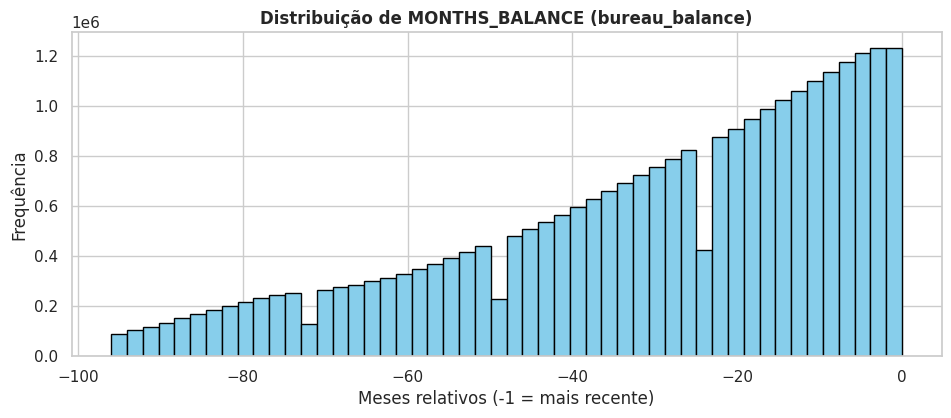

In [ ]:
meses_no_futuro = len(bureau_balance[bureau_balance['MONTHS_BALANCE'] > 0])
print(f"MONTHS_BALANCE > 0 (futuro): {meses_no_futuro}")

if meses_no_futuro == 0:
    print("Linha do tempo consistente nesta execução.")
else:
    print("Vou capar para 0 na Silver.")

plt.figure(figsize=(10, 4))
bureau_balance['MONTHS_BALANCE'].plot.hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribuição de MONTHS_BALANCE (bureau_balance)', fontsize=12, weight='bold')
plt.xlabel('Meses relativos (-1 = mais recente)')
plt.ylabel('Frequência')
plt.show()


### 3.3 Status de pagamento (`STATUS`)

Domínio esperado: `C`, `X`, `0` a `5`. Quero ver a distribuição e se aparece algo fora disso.

In [ ]:
BUREAU_STATUS_VALID = {'C', 'X', '0', '1', '2', '3', '4', '5'}

print("Distribuição de STATUS:")
status_dist = bureau_balance['STATUS'].value_counts().to_frame()
status_dist['Proporção (%)'] = (status_dist['count'] / total_linhas_bb) * 100
display(status_dist)

status_invalidos = bureau_balance[~bureau_balance['STATUS'].isin(BUREAU_STATUS_VALID)]
if len(status_invalidos) == 0:
    print("\nTodas as categorias dentro do domínio esperado.")
else:
    print(f"\n{len(status_invalidos):,} registros com STATUS fora do padrão.")

print("\nNa Gold, vou precisar agregar esses status por contrato/cliente — não dá join direto na ABT.")


Distribuição de STATUS:


,count,Proporção (%)
STATUS,,
C,13646993,49.989123
0,7499507,27.470797
X,5810482,21.283875
1,242347,0.887720
5,62406,0.228594
2,23419,0.085784
3,8924,0.032689
4,5847,0.021418



Todas as categorias dentro do domínio esperado.

Na Gold, vou precisar agregar esses status por contrato/cliente — não dá join direto na ABT.


### 3.4 Nulos

Verifico se a tabela tem colunas vazias.

In [ ]:
null_counts_bb = bureau_balance.isnull().sum()
null_percent_bb = (null_counts_bb / total_linhas_bb) * 100
missing_data_bb = pd.DataFrame({'Qtd_Nulos': null_counts_bb, 'Percentual(%)': null_percent_bb})
missing_data_bb = missing_data_bb[missing_data_bb['Qtd_Nulos'] > 0]

if len(missing_data_bb) > 0:
    print(f"{len(missing_data_bb)} colunas com nulos:")
    display(missing_data_bb)
else:
    print("Tabela 100% preenchida — sem nulos.")


Tabela 100% preenchida — sem nulos.


### Fechamento — `bureau_balance`

- Tabela enorme (~27M linhas), granularidade mensal por contrato.
- `STATUS` está dentro do domínio esperado — bom sinal.
- `MONTHS_BALANCE` sem valores no futuro nesta execução.
- Tabela 100% preenchida — não há nulos.

Não dá para jogar isso direto na ABT. Na **Gold**, preciso pivotar/agregar por `SK_ID_BUREAU` (ex.: contagem de meses em atraso nível 3+, proporção de meses fechados) e depois subir para `SK_ID_CURR`.

# 4. `POS_CASH_balance.csv`

Histórico mensal de contratos POS/cash da Home Credit. Outra tabela com granularidade mensal — mesma lógica de agregação futura.

### 4.1 Volumetria e chaves

Valido chave composta (`SK_ID_PREV` + `MONTHS_BALANCE`) e quantos contratos/clientes existem.

In [ ]:
pos_cash = pd.read_csv('POS_CASH_balance.csv')
total_linhas_pos = len(pos_cash)

chaves_duplicadas_pos = pos_cash.duplicated(subset=['SK_ID_PREV', 'MONTHS_BALANCE']).sum()
contratos_unicos_pos = pos_cash['SK_ID_PREV'].nunique()
clientes_unicos_pos = pos_cash['SK_ID_CURR'].nunique()

print(f"Registros: {total_linhas_pos:,}")
print(f"Contratos (SK_ID_PREV): {contratos_unicos_pos:,} | Clientes: {clientes_unicos_pos:,}")

if chaves_duplicadas_pos == 0:
    print("Chave composta OK.")
else:
    print(f"Duplicatas: {chaves_duplicadas_pos:,}")

print(f"Média contratos/cliente: {contratos_unicos_pos / clientes_unicos_pos:.2f}")
print(f"Média meses/contrato: {total_linhas_pos / contratos_unicos_pos:.2f}")


Registros: 10,001,358
Contratos (SK_ID_PREV): 936,325 | Clientes: 337,252
Chave composta OK.
Média contratos/cliente: 2.78
Média meses/contrato: 10.68


### 4.2 Linha do tempo (`MONTHS_BALANCE`)

Aqui o mês 0 representa o mês da aplicação (diferente do bureau_balance). Mesmo assim, futuro (>0) não deveria existir.

In [ ]:
meses_futuro_pos = len(pos_cash[pos_cash['MONTHS_BALANCE'] > 0])
print(f"MONTHS_BALANCE > 0: {meses_futuro_pos}")

if meses_futuro_pos == 0:
    print("Sem registros no futuro.")
else:
    print("Preciso limpar na Silver (cap ou drop).")


MONTHS_BALANCE > 0: 0
Sem registros no futuro.


### 4.3 Status do contrato

Quais estados um contrato POS pode assumir ao longo do tempo?

In [ ]:
status_pos_dist = pos_cash['NAME_CONTRACT_STATUS'].value_counts().to_frame()
status_pos_dist['Proporção (%)'] = (status_pos_dist['count'] / total_linhas_pos) * 100
display(status_pos_dist)
print("\nVou agregar proporção de meses por status na Gold — join direto não funciona.")


,count,Proporção (%)
NAME_CONTRACT_STATUS,,
Active,9151119,91.498764
Completed,744883,7.447819
Signed,87260,0.872482
Demand,7065,0.070640
Returned to the store,5461,0.054603
Approved,4917,0.049163
Amortized debt,636,0.006359
Canceled,15,0.000150
XNA,2,0.000020



Vou agregar proporção de meses por status na Gold — join direto não funciona.


### 4.4 Dias de atraso (`SK_DPD`)

DPD = Days Past Due. Atraso negativo não faz sentido — vou checar.

In [ ]:
atraso_negativo = len(pos_cash[pos_cash['SK_DPD'] < 0])
atraso_def_negativo = len(pos_cash[pos_cash['SK_DPD_DEF'] < 0])

print(f"SK_DPD negativo: {atraso_negativo}")
print(f"SK_DPD_DEF negativo: {atraso_def_negativo}")

print("\nMaiores atrasos registrados:")
display(pos_cash[['SK_DPD']].drop_duplicates().sort_values(by='SK_DPD', ascending=False).head(5))

if atraso_negativo == 0 and atraso_def_negativo == 0:
    print("\nDPD consistente (>= 0).")
else:
    print("\nVou aplicar floor em 0 na Silver.")


SK_DPD negativo: 0
SK_DPD_DEF negativo: 0

Maiores atrasos registrados:


,SK_DPD
7631038,4231
8724938,4200
8724934,4172
7630846,4141
8725575,4110



DPD consistente (>= 0).


### 4.5 Nulos

Especialmente `CNT_INSTALMENT` e similares — nulo pode significar contrato sem parcelamento.

In [ ]:
null_counts_pos = pos_cash.isnull().sum()
null_percent_pos = (null_counts_pos / total_linhas_pos) * 100
missing_data_pos = pd.DataFrame({'Qtd_Nulos': null_counts_pos, 'Percentual(%)': null_percent_pos})
missing_data_pos = missing_data_pos[missing_data_pos['Qtd_Nulos'] > 0].sort_values('Percentual(%)', ascending=False)

if len(missing_data_pos) > 0:
    display(missing_data_pos)
    print("\nNulos em CNT_INSTALMENT provavelmente = contrato sem parcelamento. Não imputo com média.")
else:
    print("Sem nulos.")


,Qtd_Nulos,Percentual(%)
CNT_INSTALMENT_FUTURE,26087,0.260835
CNT_INSTALMENT,26071,0.260675



Nulos em CNT_INSTALMENT provavelmente = contrato sem parcelamento. Não imputo com média.


### Fechamento — `POS_CASH_balance`

- Chave composta íntegra; ~10 meses históricos por contrato em média.
- `SK_DPD` sem valores negativos — regra simples de floor na Silver se aparecer.
- Nulos pontuais em contagem de parcelas — manter; pode significar contrato encerrado.

**Silver:** capping de `MONTHS_BALANCE` se futuro aparecer; floor em DPD.
**ABT:** agregar por `SK_ID_CURR` — proporção de meses ativos, máximo de atraso, etc.

# 5. `credit_card_balance.csv`

Faturas mensais de cartão de crédito na Home Credit. Muitas colunas financeiras (limite, saques, pagamentos).

### 5.1 Volumetria e chaves

Mesma checagem de chave composta por cartão e mês.

In [ ]:
cc_balance = pd.read_csv('credit_card_balance.csv')
total_linhas_cc = len(cc_balance)

chaves_duplicadas_cc = cc_balance.duplicated(subset=['SK_ID_PREV', 'MONTHS_BALANCE']).sum()
contratos_unicos_cc = cc_balance['SK_ID_PREV'].nunique()
clientes_unicos_cc = cc_balance['SK_ID_CURR'].nunique()

print(f"Faturas: {total_linhas_cc:,}")
print(f"Cartões: {contratos_unicos_cc:,} | Clientes: {clientes_unicos_cc:,}")

if chaves_duplicadas_cc == 0:
    print("Chave composta OK.")
else:
    print(f"Duplicatas: {chaves_duplicadas_cc:,}")


Faturas: 3,840,312
Cartões: 104,307 | Clientes: 103,558
Chave composta OK.


### 5.2 Linha do tempo

Validação de `MONTHS_BALANCE` — futuro não deveria aparecer.

In [ ]:
meses_futuro_cc = len(cc_balance[cc_balance['MONTHS_BALANCE'] > 0])
print(f"MONTHS_BALANCE > 0: {meses_futuro_cc}")
print("OK" if meses_futuro_cc == 0 else "Limpar na Silver.")


MONTHS_BALANCE > 0: 0
OK


### 5.3 Lógica financeira

Limites, saques e pagamentos não deveriam ser negativos. Percorro as colunas monetárias.

In [ ]:
colunas_nao_negativas = [
    'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT',
    'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY',
    'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'CNT_DRAWINGS_ATM_CURRENT',
    'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_OTHER_CURRENT', 'CNT_DRAWINGS_POS_CURRENT'
]

erros_financeiros = 0
for col in colunas_nao_negativas:
    if col in cc_balance.columns:
        negativos = len(cc_balance[cc_balance[col] < 0])
        if negativos > 0:
            print(f"  {col}: {negativos} negativos")
            erros_financeiros += negativos

if erros_financeiros == 0:
    print("Colunas financeiras consistentes (>= 0).")
else:
    print(f"\nTotal de violações: {erros_financeiros} — trato na Silver.")


  AMT_DRAWINGS_ATM_CURRENT: 1 negativos
  AMT_DRAWINGS_CURRENT: 3 negativos

Total de violações: 4 — trato na Silver.


### 5.4 Atrasos e status

Mesmo raciocínio do POS: DPD e status categórico do contrato.

In [ ]:
atraso_negativo_cc = len(cc_balance[cc_balance['SK_DPD'] < 0])
print(f"SK_DPD negativo: {atraso_negativo_cc}")

status_cc_dist = cc_balance['NAME_CONTRACT_STATUS'].value_counts().to_frame()
status_cc_dist['Proporção (%)'] = (status_cc_dist['count'] / total_linhas_cc) * 100
display(status_cc_dist)
print("\nNa Gold: limite médio, saques, meses com atraso — tudo por SK_ID_CURR.")


SK_DPD negativo: 0


,count,Proporção (%)
NAME_CONTRACT_STATUS,,
Active,3698436,96.305613
Completed,128918,3.356967
Signed,11058,0.287945
Demand,1365,0.035544
Sent proposal,513,0.013358
Refused,17,0.000443
Approved,5,0.000130



Na Gold: limite médio, saques, meses com atraso — tudo por SK_ID_CURR.


### 5.5 Nulos

Cartão costuma ter muitos nulos em saques/pagamentos — preciso entender se é ausência real ou 'zero implícito'.

In [ ]:
null_counts_cc = cc_balance.isnull().sum()
null_percent_cc = (null_counts_cc / total_linhas_cc) * 100
missing_data_cc = pd.DataFrame({'Qtd_Nulos': null_counts_cc, 'Percentual(%)': null_percent_cc})
missing_data_cc = missing_data_cc[missing_data_cc['Qtd_Nulos'] > 0].sort_values('Percentual(%)', ascending=False)

if len(missing_data_cc) > 0:
    display(missing_data_cc.head(10))
    print("\nMuitos nulos em saques — suspeito que nulo = zero saques naquele mês.")
    print("Vou validar essa hipótese na Silver antes de preencher com 0.")
else:
    print("Sem nulos.")


,Qtd_Nulos,Percentual(%)
AMT_PAYMENT_CURRENT,767988,19.998063
AMT_DRAWINGS_ATM_CURRENT,749816,19.524872
AMT_DRAWINGS_OTHER_CURRENT,749816,19.524872
AMT_DRAWINGS_POS_CURRENT,749816,19.524872
CNT_DRAWINGS_ATM_CURRENT,749816,19.524872
CNT_DRAWINGS_POS_CURRENT,749816,19.524872
CNT_DRAWINGS_OTHER_CURRENT,749816,19.524872
AMT_INST_MIN_REGULARITY,305236,7.948208
CNT_INSTALMENT_MATURE_CUM,305236,7.948208



Muitos nulos em saques — suspeito que nulo = zero saques naquele mês.
Vou validar essa hipótese na Silver antes de preencher com 0.


### Fechamento — `credit_card_balance`

- ~3,8M faturas; só ~34% dos clientes do train têm histórico de cartão.
- Colunas financeiras consistentes (sem negativos).
- Muitos nulos em saques — na prática, nulo provavelmente significa **zero saques** naquele mês; vou tratar na Silver com cuidado (preencher 0 só onde fizer sentido de negócio).

**ABT:** features como limite médio, total de saques ATM, meses com atraso (`SK_DPD` > 0).

# 6. `previous_application.csv`

Solicitações **anteriores** do cliente na própria Home Credit — aprovadas, recusadas, canceladas. Outra fonte rica para features de comportamento.

### 6.1 Volumetria e chave

`SK_ID_PREV` deve identificar cada aplicação anterior. Verifico unicidade.

In [ ]:
prev_app = pd.read_csv('previous_application.csv')
total_linhas_prev = len(prev_app)

chaves_unicas_prev = prev_app['SK_ID_PREV'].nunique()
clientes_unicos_prev = prev_app['SK_ID_CURR'].nunique()

print(f"Registros: {total_linhas_prev:,}")
print(f"SK_ID_PREV únicos: {chaves_unicas_prev:,}")

if total_linhas_prev == chaves_unicas_prev:
    print("Chave SK_ID_PREV OK.")
else:
    print(f"Duplicatas: {total_linhas_prev - chaves_unicas_prev:,}")

print(f"Clientes com histórico HC: {clientes_unicos_prev:,}")


Registros: 1,670,214
SK_ID_PREV únicos: 1,670,214
Chave SK_ID_PREV OK.
Clientes com histórico HC: 338,857


### 6.2 Resultado das aplicações

Qual o mix aprovado vs recusado? E quando recusam, qual o motivo mais comum?

In [ ]:
status_dist = prev_app['NAME_CONTRACT_STATUS'].value_counts(normalize=True) * 100
print("Distribuição de status:")
print(status_dist)

recusas = prev_app[prev_app['NAME_CONTRACT_STATUS'] == 'Refused']
print("\nTop motivos de recusa:")
print(recusas['CODE_REJECT_REASON'].value_counts(normalize=True).head(5) * 100)


Distribuição de status:
NAME_CONTRACT_STATUS
Approved        62.074740
Canceled        18.938831
Refused         17.403638
Unused offer     1.582791
Name: proportion, dtype: float64

Top motivos de recusa:
CODE_REJECT_REASON
HC       60.283544
LIMIT    19.155216
SCO      12.889520
SCOFR     4.407282
XNA       1.801306
Name: proportion, dtype: float64


### 6.3 Coerência financeira

Para aprovações: o valor concedido (`AMT_CREDIT`) bate com o solicitado (`AMT_APPLICATION`)?

In [ ]:
prev_app['diff_app_credit'] = prev_app['AMT_APPLICATION'] - prev_app['AMT_CREDIT']
print(f"Diferença média (solicitado - concedido): {prev_app['diff_app_credit'].mean():.2f}")
print("Valores positivos = cliente pediu mais do que recebeu (comum em aprovações parciais).")


Diferença média (solicitado - concedido): -20880.06
Valores positivos = cliente pediu mais do que recebeu (comum em aprovações parciais).


### 6.4 Nulos

Mapeamento de completude nesta tabela.

In [ ]:
null_counts = prev_app.isnull().sum()
null_percent = (null_counts / total_linhas_prev) * 100
missing_data = pd.DataFrame({'Qtd_Nulos': null_counts, 'Percentual(%)': null_percent})
display(missing_data[missing_data['Qtd_Nulos'] > 0].sort_values('Percentual(%)', ascending=False).head(10))
print("\nTabela rica para features: qtd aprovações, recusas, taxa de aprovação — tudo na Gold.")


,Qtd_Nulos,Percentual(%)
RATE_INTEREST_PRIVILEGED,1664263,99.643698
RATE_INTEREST_PRIMARY,1664263,99.643698
AMT_DOWN_PAYMENT,895844,53.636480
RATE_DOWN_PAYMENT,895844,53.636480
NAME_TYPE_SUITE,820405,49.119754
NFLAG_INSURED_ON_APPROVAL,673065,40.298129
DAYS_LAST_DUE_1ST_VERSION,673065,40.298129
DAYS_FIRST_DUE,673065,40.298129
DAYS_FIRST_DRAWING,673065,40.298129
DAYS_LAST_DUE,673065,40.298129



Tabela rica para features: qtd aprovações, recusas, taxa de aprovação — tudo na Gold.


### Fechamento — `previous_application`

- Mix claro entre aprovados, recusados e cancelados — ótimo para features de comportamento.
- Motivos de recusa categorizados (`CODE_REJECT_REASON`).
- Tabela com muitas colunas e nulos — esperado dado que campos mudam conforme status.

**ABT:** contagem de aprovações/recusas, taxa de aprovação, valor médio solicitado vs concedido — tudo agregado por `SK_ID_CURR`.

# 7. `installments_payments.csv`

Pagamento **parcela a parcela** dos contratos anteriores. Granularidade fina — e notei no dicionário que pode haver mais de um pagamento por parcela.

### 7.1 Volumetria e chave composta

Espero 1 linha por `SK_ID_PREV` + `NUM_INSTALMENT_NUMBER`, mas suspeito que pagamentos fracionados podem gerar duplicatas.

In [ ]:
installments = pd.read_csv('installments_payments.csv')
total_linhas_inst = len(installments)

chaves_duplicadas_inst = installments.duplicated(subset=['SK_ID_PREV', 'NUM_INSTALMENT_NUMBER']).sum()
contratos_unicos_inst = installments['SK_ID_PREV'].nunique()

print(f"Registros: {total_linhas_inst:,}")
print(f"Contratos: {contratos_unicos_inst:,}")

if chaves_duplicadas_inst == 0:
    print("1 linha por parcela — granularidade esperada.")
else:
    print(f"{chaves_duplicadas_inst:,} duplicatas — pagamentos fracionados na mesma parcela.")
    print("Na Gold: agrupar por SK_ID_PREV + NUM_INSTALMENT_NUMBER e somar AMT_PAYMENT.")


Registros: 13,605,401
Contratos: 997,752
743,407 duplicatas — pagamentos fracionados na mesma parcela.
Na Gold: agrupar por SK_ID_PREV + NUM_INSTALMENT_NUMBER e somar AMT_PAYMENT.


### 7.2 Datas e atraso

Comparo data de vencimento vs data de pagamento para estimar atraso. Também checo datas no futuro.

In [ ]:
vencimento_futuro = len(installments[installments['DAYS_INSTALMENT'] > 0])
pagamento_futuro = len(installments[installments['DAYS_ENTRY_PAYMENT'] > 0])

print(f"Vencimento no futuro: {vencimento_futuro}")
print(f"Pagamento no futuro: {pagamento_futuro}")

installments['DIAS_DE_ATRASO'] = installments['DAYS_ENTRY_PAYMENT'] - installments['DAYS_INSTALMENT']
atrasos = len(installments[installments['DIAS_DE_ATRASO'] > 0])
adimplentes = len(installments[installments['DIAS_DE_ATRASO'] <= 0])

print(f"\nParcelas pagas com atraso: {atrasos:,} ({atrasos/total_linhas_inst*100:.1f}%)")
print(f"No prazo ou adiantado: {adimplentes:,} ({adimplentes/total_linhas_inst*100:.1f}%)")


Vencimento no futuro: 0
Pagamento no futuro: 0

Parcelas pagas com atraso: 1,146,669 (8.4%)
No prazo ou adiantado: 12,455,827 (91.6%)


### 7.3 Valores cobrados vs pagos

O cliente pagou o valor integral da parcela? Pagou menos? Não pagou nada?

In [ ]:
negativos_cobrados = len(installments[installments['AMT_INSTALMENT'] < 0])
negativos_pagos = len(installments[installments['AMT_PAYMENT'] < 0])
print(f"AMT_INSTALMENT negativo: {negativos_cobrados}")
print(f"AMT_PAYMENT negativo: {negativos_pagos}")

installments['FALTA_PAGAR'] = installments['AMT_INSTALMENT'] - installments['AMT_PAYMENT']
pagaram_menos = len(installments[installments['FALTA_PAGAR'] > 0])
print(f"\nParcelas com pagamento menor que o cobrado: {pagaram_menos:,} ({pagaram_menos/total_linhas_inst*100:.1f}%)")


AMT_INSTALMENT negativo: 0
AMT_PAYMENT negativo: 0

Parcelas com pagamento menor que o cobrado: 1,295,493 (9.5%)


### 7.4 Nulos — atenção especial em pagamento

Se `AMT_PAYMENT` está nulo, preciso entender o que isso significa na prática.

In [ ]:
null_counts_inst = installments.isnull().sum()
null_percent_inst = (null_counts_inst / total_linhas_inst) * 100
missing_data_inst = pd.DataFrame({'Qtd_Nulos': null_counts_inst, 'Percentual(%)': null_percent_inst})
missing_data_inst = missing_data_inst[missing_data_inst['Qtd_Nulos'] > 0].sort_values('Percentual(%)', ascending=False)

if len(missing_data_inst) > 0:
    display(missing_data_inst)
    print("\nAMT_PAYMENT nulo = cliente não pagou a parcela.")
    print("Na Silver: preencher AMT_PAYMENT nulo com 0.0 para os cálculos de inadimplência funcionarem.")
else:
    print("Sem nulos.")


,Qtd_Nulos,Percentual(%)
DAYS_ENTRY_PAYMENT,2905,0.021352
AMT_PAYMENT,2905,0.021352
DIAS_DE_ATRASO,2905,0.021352
FALTA_PAGAR,2905,0.021352



AMT_PAYMENT nulo = cliente não pagou a parcela.
Na Silver: preencher AMT_PAYMENT nulo com 0.0 para os cálculos de inadimplência funcionarem.


### Fechamento — `installments_payments`

- ~13,6M linhas; parcelas podem ter **múltiplos pagamentos** (pagamento fracionado) — preciso agrupar antes de agregar.
- `DIAS_DE_ATRASO` = diferença entre pagamento e vencimento — feature valiosa para Gold.
- **`AMT_PAYMENT` nulo = calote** (cliente não pagou). Na Silver, preencher com 0.0 para os cálculos de 'quanto faltou pagar' funcionarem.

**ABT:** taxa de atraso média, proporção de parcelas com pagamento parcial, valor total em aberto.

---
# 8. Integridade referencial entre tabelas

Depois de olhar cada tabela isoladamente, quero cruzar as chaves estrangeiras antes de pensar no join da ABT. Órfãos aqui podem indicar problema de dados **ou** clientes que estão no `application_test` e não no `application_train`.

In [ ]:
def check_fk(child, child_col, parent, parent_col, child_name, parent_name):
    child_vals = set(child[child_col].dropna().unique())
    parent_vals = set(parent[parent_col].dropna().unique())
    orphans = child_vals - parent_vals
    print(f"\n{child_name}.{child_col} -> {parent_name}.{parent_col}")
    print(f"  Únicos no filho: {len(child_vals):,}")
    print(f"  Órfãos: {len(orphans):,}")
    if len(orphans) == 0:
        print('  OK — integridade referencial')
    else:
        print('  Órfãos encontrados — pode ser clientes do application_test')
    return len(orphans)

print('=' * 55)
print('CRUZAMENTO DE CHAVES ENTRE TABELAS')
print('=' * 55)

check_fk(bureau, 'SK_ID_CURR', app_train, 'SK_ID_CURR', 'bureau', 'application_train')
check_fk(bureau_balance, 'SK_ID_BUREAU', bureau, 'SK_ID_BUREAU', 'bureau_balance', 'bureau')
check_fk(pos_cash, 'SK_ID_CURR', app_train, 'SK_ID_CURR', 'POS_CASH', 'application_train')
check_fk(cc_balance, 'SK_ID_CURR', app_train, 'SK_ID_CURR', 'credit_card', 'application_train')
check_fk(prev_app, 'SK_ID_CURR', app_train, 'SK_ID_CURR', 'previous_application', 'application_train')
check_fk(installments, 'SK_ID_PREV', prev_app, 'SK_ID_PREV', 'installments', 'previous_application')

print('\n--- Cobertura: quantos clientes do train têm histórico em cada fonte ---')
fontes = {
    'bureau': bureau['SK_ID_CURR'].nunique(),
    'POS_CASH': pos_cash['SK_ID_CURR'].nunique(),
    'credit_card': cc_balance['SK_ID_CURR'].nunique(),
    'previous_application': prev_app['SK_ID_CURR'].nunique(),
}
total_app = app_train['SK_ID_CURR'].nunique()
cobertura = pd.DataFrame({
    'Clientes_Unicos': fontes,
    'Pct_do_Application': {k: v/total_app*100 for k, v in fontes.items()}
}).round(1)
display(cobertura)

print('\nPOS e previous_application > 100% — faz sentido: essas tabelas incluem clientes do test set.')
print('Na ABT de treino: LEFT JOIN a partir de application_train; sem histórico vira feature (ex: HAS_BUREAU=0).')


CRUZAMENTO DE CHAVES ENTRE TABELAS

bureau.SK_ID_CURR -> application_train.SK_ID_CURR
  Únicos no filho: 305,811
  Órfãos: 42,320
  Órfãos encontrados — pode ser clientes do application_test

bureau_balance.SK_ID_BUREAU -> bureau.SK_ID_BUREAU
  Únicos no filho: 817,395
  Órfãos: 43,041
  Órfãos encontrados — pode ser clientes do application_test

POS_CASH.SK_ID_CURR -> application_train.SK_ID_CURR
  Únicos no filho: 337,252
  Órfãos: 47,808
  Órfãos encontrados — pode ser clientes do application_test

credit_card.SK_ID_CURR -> application_train.SK_ID_CURR
  Únicos no filho: 103,558
  Órfãos: 16,653
  Órfãos encontrados — pode ser clientes do application_test

previous_application.SK_ID_CURR -> application_train.SK_ID_CURR
  Únicos no filho: 338,857
  Órfãos: 47,800
  Órfãos encontrados — pode ser clientes do application_test

installments.SK_ID_PREV -> previous_application.SK_ID_PREV
  Únicos no filho: 997,752
  Órfãos: 38,847
  Órfãos encontrados — pode ser clientes do application_tes

,Clientes_Unicos,Pct_do_Application
bureau,305811,99.4
POS_CASH,337252,109.7
credit_card,103558,33.7
previous_application,338857,110.2



POS e previous_application > 100% — faz sentido: essas tabelas incluem clientes do test set.
Na ABT de treino: LEFT JOIN a partir de application_train; sem histórico vira feature (ex: HAS_BUREAU=0).


### Fechamento — integridade referencial

Os órfãos que apareceram **não são necessariamente erro** — as tabelas auxiliares cobrem clientes do `application_test` também, e eu cruzei só com o train.

- Cobertura do bureau: ~99% dos clientes do train têm histórico externo.
- POS e `previous_application` passam de 100% porque incluem SK_ID_CURR do test set.
- Na **ABT de treino**: LEFT JOIN a partir de `application_train`; cliente sem histórico vira feature binária (`HAS_BUREAU=0`, `HAS_POS_CASH=0`, etc.).

Isso fecha o mapa mental: explorei cada tabela, anotei problemas, e agora sei como juntar sem explodir a granularidade.

---
# 9. Consolidando minhas anotações

Reuni abaixo tudo o que encontrei ao longo do notebook — problema, tratamento sugerido e em qual camada aplicar. Isso vira o roteiro para `data_sanitization.py` (Silver) e `abt_transform.py` (Gold).

In [ ]:
mapa_tratamentos = pd.DataFrame([
    ['application_train', 'DAYS_EMPLOYED', 'Anomalia 365243 + >50 anos', 'NaN + criar FLAG_EMPLOYED', 'Silver'],
    ['application_train', 'CODE_GENDER', 'Categoria XNA inválida', 'Mapear para NaN/UNKNOWN', 'Silver'],
    ['application_train', 'OWN_CAR_AGE', 'Nulo condicional (sem carro)', 'NaN se FLAG_OWN_CAR=N', 'Silver'],
    ['application_train', 'EXT_SOURCE_*', '~55% nulos em EXT_SOURCE_1', 'Manter nulos + flag ausência', 'Silver/Gold'],
    ['application_train', 'EXT_SOURCE_MEAN/CNT', 'Scores combinados', 'Calcular na Gold', 'Gold'],
    ['application_train', 'LOG_AMT_CREDIT', 'AMT_CREDIT assimétrico', 'log1p na Gold', 'Gold'],
    ['application_train', 'Faixa etária', 'Tendência por idade', 'AGE_YEARS ou bins na Gold', 'Gold'],
    ['application_train', 'CREDIT_INCOME_RATIO', 'Feature derivada', 'Calcular na Gold', 'Gold'],
    ['application_train', 'Colunas imóvel (_AVG/_MODE)', '~70% nulos', 'Não imputar', 'Silver'],
    ['bureau', 'DAYS_CREDIT_ENDDATE', 'Previsão > 50 anos', 'Converter para NaN', 'Silver'],
    ['bureau', 'AMT_CREDIT_SUM', 'Outliers astronômicos', 'Capping P99.9', 'Silver'],
    ['bureau_balance', 'STATUS', 'Domínio [C,X,0-5]', 'UPPER/TRIM + validar', 'Silver'],
    ['bureau_balance', 'MONTHS_BALANCE', 'Futuro > 0', 'Capping para 0', 'Silver'],
    ['POS_CASH / credit_card', 'SK_DPD', 'Valores negativos', 'Floor em 0', 'Silver'],
    ['POS_CASH / credit_card', 'MONTHS_BALANCE', 'Futuro > 0', 'Capping para 0', 'Silver'],
    ['previous_application', 'DAYS_*', 'Anomalia 365243', 'NaN se > 18250 dias', 'Silver'],
    ['installments_payments', 'AMT_PAYMENT', 'Nulo = calote', 'Preencher com 0.0', 'Silver'],
    ['installments_payments', 'Pagamentos fracionados', 'Múltiplas linhas/parcela', 'GroupBy + sum na Gold', 'Gold'],
    ['Todas auxiliares', 'SK_ID_CURR', 'Agregação', 'GroupBy features por cliente', 'Gold'],
], columns=['Tabela', 'Coluna/Feature', 'Problema', 'Tratamento', 'Camada'])

display(mapa_tratamentos)

print('\n' + '='*55)
print('PRÓXIMOS PASSOS (a partir desta EDA)')
print('='*55)
print('1. Silver — data_sanitization.py com as regras acima')
print('2. Silver — processar application_test.csv com as mesmas regras')
print('3. Gold — agregar auxiliares por SK_ID_CURR → abt.parquet')
print('4. Modelo — LightGBM com ROC-AUC (desbalanceamento ~8%)')
print('\nEDA concluída. Parto para a Camada Silver.')


,Tabela,Coluna/Feature,Problema,Tratamento,Camada
0,application_train,DAYS_EMPLOYED,Anomalia 365243 + >50 anos,NaN + criar FLAG_EMPLOYED,Silver
1,application_train,CODE_GENDER,Categoria XNA inválida,Mapear para NaN/UNKNOWN,Silver
2,application_train,OWN_CAR_AGE,Nulo condicional (sem carro),NaN se FLAG_OWN_CAR=N,Silver
3,application_train,EXT_SOURCE_*,~55% nulos em EXT_SOURCE_1,Manter nulos + flag ausência,Silver/Gold
4,application_train,EXT_SOURCE_MEAN/CNT,Scores combinados,Calcular na Gold,Gold
5,application_train,LOG_AMT_CREDIT,AMT_CREDIT assimétrico,log1p na Gold,Gold
6,application_train,Faixa etária,Tendência por idade,AGE_YEARS ou bins na Gold,Gold
7,application_train,CREDIT_INCOME_RATIO,Feature derivada,Calcular na Gold,Gold
8,application_train,Colunas imóvel (_AVG/_MODE),~70% nulos,Não imputar,Silver
9,bureau,DAYS_CREDIT_ENDDATE,Previsão > 50 anos,Converter para NaN,Silver



PRÓXIMOS PASSOS (a partir desta EDA)
1. Silver — data_sanitization.py com as regras acima
2. Silver — processar application_test.csv com as mesmas regras
3. Gold — agregar auxiliares por SK_ID_CURR → abt.parquet
4. Modelo — LightGBM com ROC-AUC (desbalanceamento ~8%)

EDA concluída. Parto para a Camada Silver.
